# Phase Two: Feature Engineering

In [7]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent / "src"))

In [11]:
from ipywidgets import interact
from IPython.display import display


import importlib

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn import linear_model

from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from data import DatasetLoader, utils
from models import NDVIClimatologyGAM



## Load Data

In [12]:
loader = DatasetLoader(raw_data_dir="../data/raw/", engineered_data_dir="../data/processed/")
non_spectral_df = loader.non_spectral()
grouped_spectral_df = loader.grouped_spectral()
master_df = utils.merge_with_master(grouped_spectral_df, non_spectral_df)
master_df.head()

,Timestamp,NDVI_mean,NDVI_std,NDWI_mean,NDWI_std,NDRE_mean,NDRE_std,volumetric_soil_water_layer_1,volumetric_soil_water_layer_2,volumetric_soil_water_layer_3,volumetric_soil_water_layer_4,soil_temperature_level_1,soil_temperature_level_2,soil_temperature_level_3,soil_temperature_level_4,temperature_2m,temperature_2m_min,temperature_2m_max,surface_solar_radiation_downwards_sum,precipitation
0,2018-01-07,0.454175,0.017789,0.154850,0.001513,0.301027,0.005391,0.277943,0.320916,0.297231,0.270322,298.093380,296.435354,293.480139,291.139993,296.411982,288.101550,305.198672,3.187154e+07,0.000000
1,2018-03-03,0.629801,0.031419,0.310717,0.025493,0.438958,0.033150,0.275499,0.294964,0.281848,0.269882,296.319232,295.264591,293.797097,292.708587,293.174303,284.739623,300.874879,2.653625e+07,5.928807
2,2018-06-01,0.330054,0.013942,0.073200,0.005519,0.220654,0.008582,0.387392,0.309780,0.338261,0.271122,283.614288,284.567219,286.777798,290.473939,281.743066,275.021431,288.422674,1.504906e+07,0.000000
3,2018-06-06,0.289118,0.015937,-0.017437,0.002453,0.180388,0.010207,0.336953,0.310565,0.336209,0.271163,281.924616,282.769941,285.820755,290.178382,280.752142,274.098569,288.798194,1.452415e+07,0.000000
4,2018-06-11,0.264834,0.027659,-0.018403,0.011886,0.172670,0.016877,0.307676,0.305746,0.333914,0.271199,282.930785,283.265651,285.249282,289.847651,281.838309,276.769477,289.060574,1.396338e+07,0.000000


---

---

## Growth Stages

In the feature engineering chapters to follow, we will see that the relative growth stages of maize plays an integral role in defining the influence and interpretation of many of the environmental variables in our dataset. The challenge in an unsupervised learning problem like this is the fact that we don't have access to labels detailing the growth stages of the crop, so it takes some creativity to approximately classify where in the process our crop field is. 

Maize growth is divided into two main categories, **Vegetative (V)** and **Reproductive (R)**. The vegatative ranking is determined by the amount of visible collars on the plant. 

<img src="assets/maize_collars.jpg" width="350">

The plants grow up to a V18 or V21 stage, where-after it goes into a reproductive stage and loses its greenery. 

<img src="assets/V_n_R.jpg" width="500">



### Introducing NDVI


Why is all this important? For the simple reason that one of our spectral indices, NDVI, is as such a measurement of the "greenery" of the maize crops. More concretely, a higher NDVI tells us that the vegatation in the area under consideration reflects more near-infrared and green light as compared to other wave-lengths, but absorbs more blue and red. The higher the NDVI, the healthier and more green is the crop. In other words, as greenery increases starting from planting season, the average NDVI graph will give us a good indication of the growth stages of the maize.


$$\text{NDVI}=\frac{\text{NIR} - \text{Red}}{\text{NIR} + \text{Red}}$$

In [13]:
plot_df = master_df[master_df["Timestamp"] < pd.to_datetime("2026-01-01")].copy()
plot_df = plot_df.sort_values("Timestamp")
plot_df["doy"] = plot_df["Timestamp"].dt.dayofyear

#jul1_doy = pd.Timestamp("2021-07-01").dayofyear
#plot_df["doy"] = ((plot_df["Timestamp"].dt.dayofyear - jul1_doy) % 365) + 1


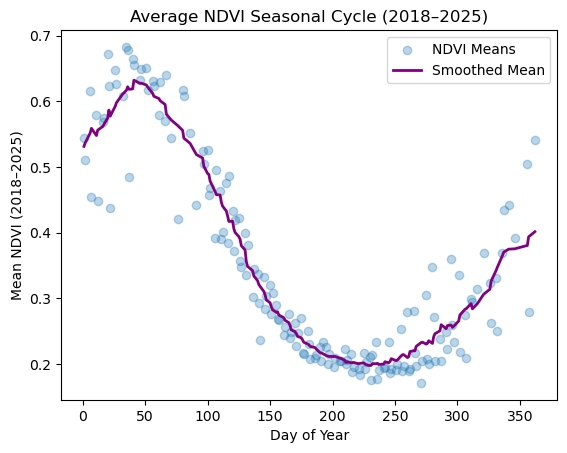

In [14]:

clim = plot_df.groupby("doy")["NDVI_mean"].mean().sort_index()
clim_smooth = clim.rolling(window=14, center=True, min_periods=1).mean()

plt.figure()
plt.scatter(clim.index, clim.values, alpha=0.3, label="NDVI Means")
plt.plot(clim_smooth.index, clim_smooth.values, linewidth=2, label="Smoothed Mean", color="purple")
plt.xlabel("Day of Year")
plt.ylabel("Mean NDVI (2018–2025)")
plt.title("Average NDVI Seasonal Cycle (2018–2025)")
plt.legend()
plt.show()

While the above graph certainly gives us a good picture of the **average** cycle of NDVI throughout the year, there are a few issues. First, this is purely the mean of means. There is a large discontinuity between the two end-points of the graph and therefore it is not cyclic. It is by no means a robust estimator of the NDVI cycle and therefore its residuals and derivatives should not be trusted for inference. Crucially, all these issues can mostly be solved by fitting a **Generalised Additive Model** (GAM) to our NDVI data. 

We first shift the DOY axis so that the growing season does not "carry over" to the following year. This will provide is with better behaviour from the cyclic spline. 

In [15]:
shift = pd.Timestamp("2019-08-01").dayofyear

def shift_doy(x):
    shifted_doy = ((x - shift) % 365) + 1
    return shifted_doy

def inv_shift_doy(x):
    inv_shifted_doy = (x + shift - 1) % 365
    return inv_shifted_doy

In [16]:
# Shift data to approximately before the start of the growing steason
shifted_doy = ((plot_df["Timestamp"].dt.dayofyear - shift) % 365) + 1
plot_df["shifted_doy"] = shifted_doy

doys = np.arange(1, 366)
agr_doys = ((doys - shift) % 365) + 1

# Define x-ticks for shifted axis
x_ticks = np.arange(1, 366, 30)
x_labels = ((x_ticks + shift - 1) % 365) + 1

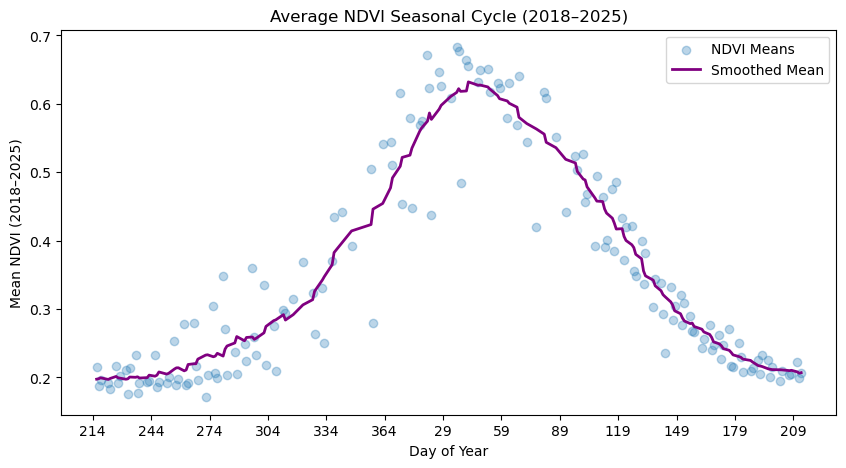

In [17]:

clim = plot_df.groupby("shifted_doy")["NDVI_mean"].mean().sort_index()
clim_smooth = clim.rolling(window=14, center=True, min_periods=1).mean()

plt.figure(figsize=(10, 5))
plt.scatter(clim.index, clim.values, alpha=0.3, label="NDVI Means")
plt.plot(clim_smooth.index, clim_smooth.values, linewidth=2, label="Smoothed Mean", color="purple")

plt.xticks(ticks = x_ticks, labels=x_labels)

plt.xlabel("Day of Year")
plt.ylabel("Mean NDVI (2018–2025)")
plt.title("Average NDVI Seasonal Cycle (2018–2025)")
plt.legend()
plt.show()

This shift is not at all aligned with our true start-of-season, but it does give us a nice bell curve for when fitting our GAM.

#### Seasonal Cyclic GAM

We will make use of a cyclic GAM fit on NDVI against DOY. The cyclic constraint of the cubic spline ensures our predicted curve and its derivatives match at the start and end of the year. This is _not_ a model intended for prediction. Instead it is a model of climatology - an "average" movement of NDVI over all the DOY's of the dataset. 

100% (25 of 25) |########################| Elapsed Time: 0:00:00 Time:  0:00:000:00


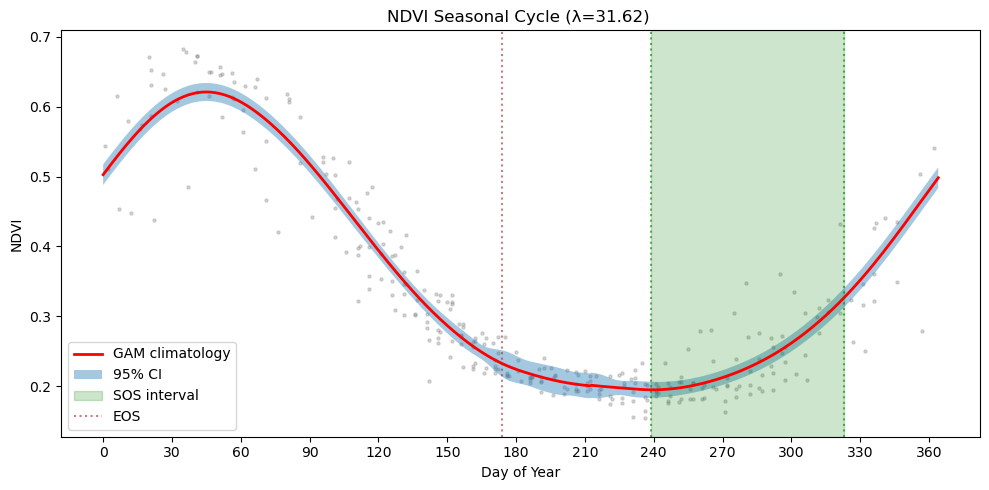

In [18]:
gam = NDVIClimatologyGAM(n_splines=30)

X = master_df["Timestamp"].dt.dayofyear.values.reshape(-1, 1)
y = master_df["NDVI_mean"].values

gam.gridsearch(doys=X, ndvi=y)
gam.plot_climatology(season_lines=True, shifted=False)


The function under consideration is $$NDVI_i = f(\text{DOY}_i)+\epsilon_i$$
where the GAM is estimating $f(\text{DOY}_i)$ i.e. estimating the average NDVI seasonal cycle as a function of the day of year (DOY). This gives us an interpolated seasonal curve, with the ability to find $f'(d)$ which will give us the average green-up rate of the crops.

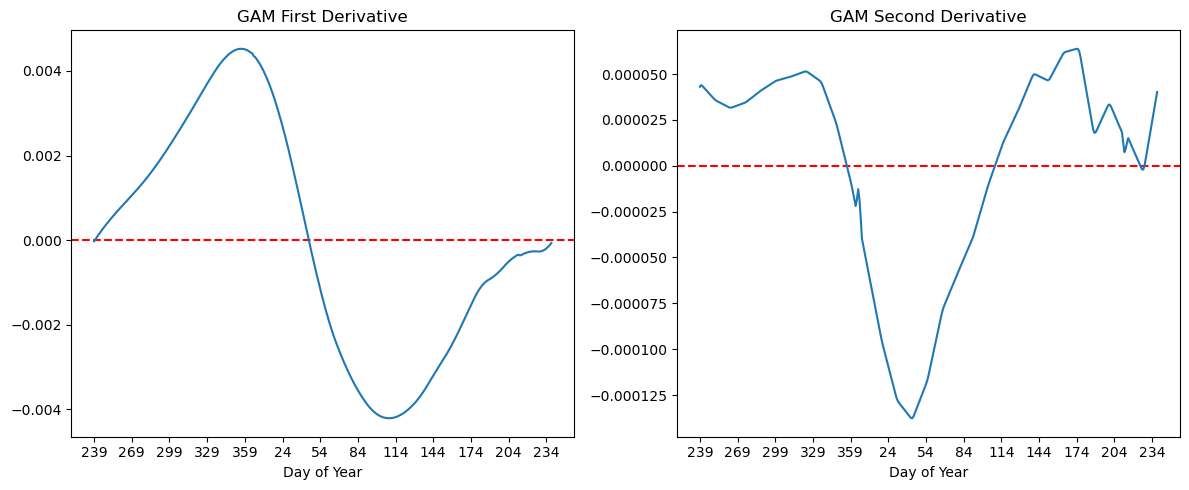

In [22]:
gam.plot_derivatives(shifted=True, crit_lines=False)

In [24]:
gam.summary()

ClimatologyGAM
────────────────────────────────────────────────────────────
Observations                   305
Response                       NDVI

Phenological Events
────────────────────────────────────────────────────────────
Start-of-Season interval       (239, 323)
Selected SOS DOY               239
Peak Growth                    TODO
Senescence DOY                 174

Seasonal Metrics
────────────────────────────────────────────────────────────
Season Length                  300
Peak NDVI                      0.68
Base NDVI                      0.15
Average NDVI                   0.32


The `LinearGAM` has a first derivative representing the change in NDVI per individual day, while the second derivative describes the relative acceleration/deceleration of greening within the crops.

- The zero crossing of the first derivative ($f'(x)=0$) represents the absolute minimum of the vegetative cycle. This is the moment the ecosystem transititions from dormancy to growth.
- The second derivative $f''(x)$ has two peaks. The first peak can be interpreted as the moment the canopy developments hits its maximum acceleration. The second peak is the "leveling off" after the end-of-season NDVI drop.

### Start-of-Season

It is not difficult to see that our average **Start of Season** DOY will almost certainly be between the zero-crossing of the first derivative and the first peak of the second derivative. To find this DOY, we have to:
1. Find the zero crossing (from negative to positive) in the $dy/dx$ curve,
2. Find the peak of the second derivative _before the winter season_.

In [25]:
gam.sos_interval

(239, 323)

We can specify where in the interval we want our SOS to be. There is no clear-cut answer to which is the best, as it varies by year.

In [30]:
sos = gam.start_of_season(position='late')
print(sos)

302


### End-of-Season

Now to define our **End of Season**, we follow similar logic. The lowest negative value of $f'(x)$ is the point where the canopy is losing greenery at the fastest rate. The local minimum of $f''(x)$ represents the moment the crop crash hits its maximum downward acceleration, i.e. the leaves are browning at a faster rate each day. The decay has to stabilise at some point - therefore the second peak of $f''(x)$ is the "dormancy date" - the seasonal change has finished and the field remains dormant. This will be our EoS.

In [31]:
eos = gam.end_of_season()
print(eos)

174


Keep in mind that this EOS is the year _after_ the SOS, which is why its DOY is less than that of SOS.

### Growing Degree Days

GDDs are a heuristic used to measure heat accumulation to predict plant development rates. If the crops aren't heavily stressed by other anomalous environmental factors, the development rate from emergence to maturity depends on daily temperature. The variant we will use is:

$$GDD=\text{max}\left\{\frac{T_\text{max}+T_\text{min}}{2}-T_\text{base}, 0\right\}$$

Corn typically has 800 to 2700 GDD to crop maturity, with a recommended baseline of 10 °C.

#### Cummulative GDD

We now start the process for the feature `Cumulative_GDD`. This feature is zero throughout the whole season *until* the moment growing season starts. In the absense of extreme environmental anomalies, the maturity of the crops can in essence be seen as a function of daily temperature. The `Cumulative_GDD` will therefore give us a good indication of the current growing stage of the crop. Note that this features resets to 0 each year when the growing season has ended.

How do we define when the cumulation starts and ends for each year? We use the **zero-crossing** and point of dormancy we found using our cyclic GAM. 

We will be using the `non_spectral_df` dataset for this, since GDD does not need NDVI to be calculated, so we can use all daily observations from beginning 2018 to end 2025. 


Our first important step for this process is to account for the fact that the full growth season does not take place within a single calendar year, so `.groupby()` breaks a season in half. This issue extends to another issue in that we have multiple years' worth of data. Without a "pointer" to a specific growth season/year, we will just be summing all the multi-year GDD's corresponding to some $DOY$. 

Therefore we define a new feature called `Ag_year`, i.e. the agricultural year under consideration spanning from the start of the growing season until after the harvest. 

To see how `Ag_year` works, consider some arbitrary DOY $t$ with corresponding year $y$. 
$$\therefore \text{AG-year}(t, y) = \begin{cases} y & \text{if } t \ge SOS \\ y-1 & \text{otherwise} \end{cases}$$

We must also account for the fact that our end-of-season cutoff is $t \in [SOS, \ EOS]$. We create a variable called `in_season` for this, where 
$$
\text{in\_season}(t) = 
\begin{cases} 
1 & \text{if } SOS \le t \le EOS \\
0 & \text{otherwise} 
\end{cases}
$$

In [33]:
# show code + df

Finally, the total sum feature can be created.

In [134]:
# show code + df

We can visualise the cumulative GDD along with NDVI to check if we have structured everything correctly. Let's consider only 2024 for this example.

In [35]:
# plot gtowth without stages

### Labeling Growth Stages using GDD

https://www.cropscience.bayer.us/articles/bayer/corn-growth-stages-and-gdu-requirements

Using the resource above, we define the labels for the vegetative stages corresponding to the cumulative GDD's feature.

| **Corn Growth Stage** | **Fahrenheit GDD** | **Celsius GDD** |
|-----------------------|--------------------|-----------------|
| VE (Emergence)        | 100 – 120          | 56 – 67         |
| V2                    | 200                | 111             |
| V4                    | 360                | 200             |
| V6                    | 520                | 289             |
| V8 to V9              | 680 – 760          | 378 – 422       |
| V12                   | 900                | 500             |
| V13                   | 955                | 531             |
| V16                   | 1,150              | 639             |
| V17+                  | 1,300              | 722             |
| VT (Tasseling)        | 1,350              | 750             |
| R1 – Silking          | 1,500              | 833             |
| R2 – Blister          | 1,700              | 944             |
| R3 – Milk             | 1,875              | 1,042           |
| R4 – Dough            | 1,950              | 1,083           |
| R5 – Dent             | 2,300              | 1,278           |
| R6 – Black Layer      | 2,700              | 1,500           |


In [36]:
# show growth df

To illustrate how we label  the growth stages for different years, we use the interaction widget. Each step in the widget plots a graph for the corresponding agricultural year, showing the  NDVI, our approximate growth labels, and the approximate cummulative GDD.

In [37]:
# plot growth with stages

---

## Soil Layers

Maize crops are deep-rooted - the bulk of functional roots is not at maximum depth. It typically remains in the upper profile, i.e. 0-30cm, with depths exceeding 120cm important during _drought_ periods. 


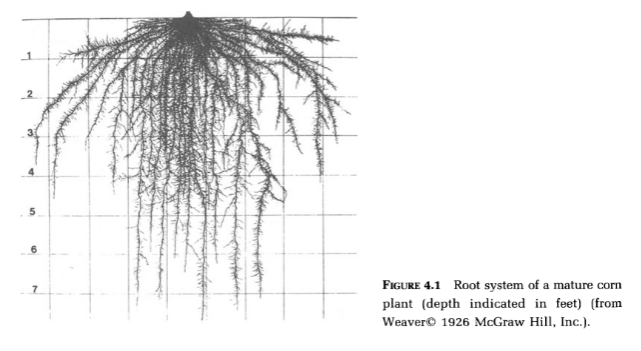

https://link.springer.com/chapter/10.1007/978-1-4612-2694-9_4 


Naturally considering these as predictors for any model introduces a significant amount of multicolinearity. One might think that dimensionality reduction would be a valid approach to address this issue, however there is a caveat - a climate shock will not have a noteworthy influence on the deep layers in a similar way that it may have on the volatile shallow levels. We must avoid a situation where these deeper layers are used mathematical anchors such  that a large change in the shallow layers will be circumvented by an insignifcant change in the deeper layers. 


### Volumetric Soil Water Layer

As stated above, the deeper layers are typically not the most important when it comes to the maize's health. This leads us to two potential paths forward:

1. **Root weighted averaging depending on growth stage**: A maize plant in its early growth stages will not have a penetrating root system at 180cm, but a mature maize plant will. We therefore introduce as features **root-zone soil moisture** ($SM_{e}$, $SM_m$, $SM_{M}$) for the *early* ($V_E-V_6$ ), *median* ($V_6-V_8$) and *mature* ($V_{12}-V_T$) **vegetation** stages of the crop, respectively. We also define $SM_{R1} - SM_{R6}$ for the **reproductive** stages of the crop.


3. **Principal Component Analysis** as observed in the _Phase 1: EDA_ notebook. 




In [140]:
prefix = "volumetric_soil_water_layer"
layers = range(1, 5)
vw_df = engineered_df[[f"{prefix}_{l}" for l in layers]].copy()
vw_df[["Growth_Stage", "shifted_doy", "Timestamp"]] = engineered_df[["Growth_Stage", "shifted_doy", "Timestamp"]].copy()
vw_df.head()

,volumetric_soil_water_layer_1,volumetric_soil_water_layer_2,volumetric_soil_water_layer_3,volumetric_soil_water_layer_4,Growth_Stage,shifted_doy,Timestamp
0,0.371225,0.394800,0.302474,0.270380,SoS,67,2018-01-01
1,0.347555,0.379907,0.302010,0.270373,SoS,68,2018-01-02
2,0.330737,0.367946,0.301465,0.270366,SoS,69,2018-01-03
3,0.315402,0.356416,0.300741,0.270358,SoS,70,2018-01-04
4,0.302094,0.344448,0.299777,0.270349,SoS,71,2018-01-05


#### 1. Root-weighted averaging

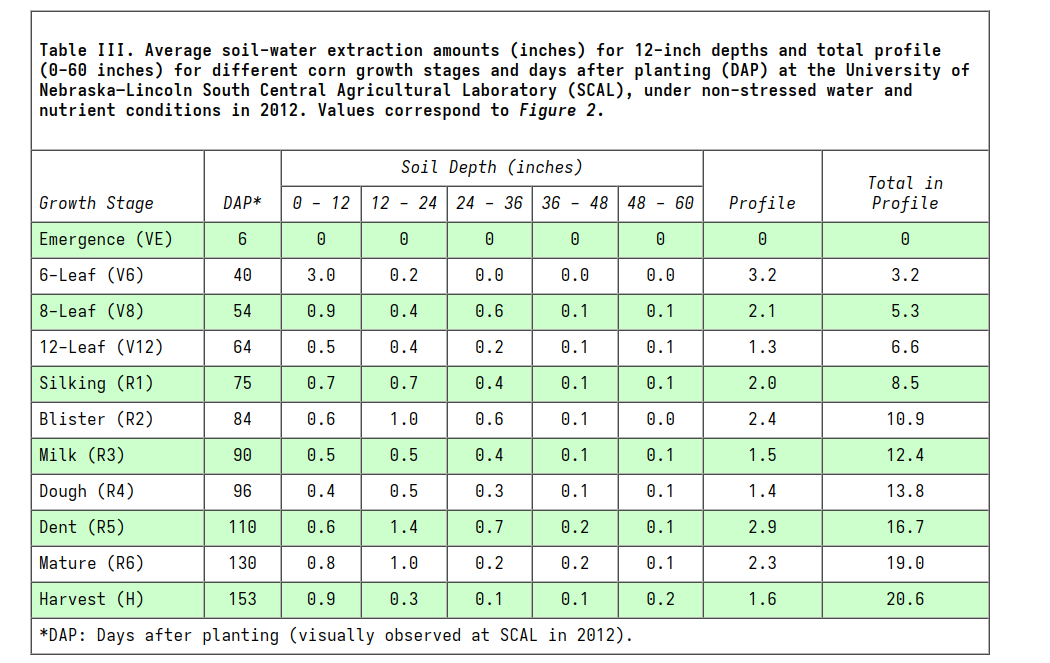

https://extensionpubs.unl.edu/publication/g2245/2014/html/view

The above table gives us the average soil-water extraction amounts for different corn growth stages in a Silt-Loam Soil (provided by SCAL). We will use the proportion of water extracted at each soil depth as the estimate of the weight corresponding to our ERA5 soil layer. 

We form the linear combinations for the **vegetative** stages:
$$\begin{align}
SM_e &= 0.9375(SM_{0-28})+0.0625(SM_{28-100}) \\
SM_m &= 0.4285(SM_{0-28} + 0.4762(SM_{28-100}) + 0.0953(SM_{100-289})) \\
SM_M &= 0.3846(SM_{0-28}) + 0.4615(SM_{28-100}) + 0.1538(SM_{100-289})
\end{align}$$

And the linear combinations for the **reproductive** stages:
$$\begin{align}
SM_{R1} &= 0.3500(SM_{0-28}) + 0.5500(SM_{28-100}) + 0.1000(SM_{100-289}) \\ 
SM_{R2} &= 0.2500(SM_{0-28}) + 0.6667(SM_{28-100}) + 0.0417(SM_{100-289})\\ 
SM_{R3} &= 0.3333(SM_{0-28}) + 0.6000(SM_{28-100}) + 0.1333(SM_{100-289})\\ 
SM_{R4} &= 0.2857(SM_{0-28}) + 0.5714(SM_{28-100}) + 0.1429(SM_{100-289})\\ 
SM_{R5} &= 0.2069(SM_{0-28}) + 0.7241(SM_{28-100}) + 0.1034(SM_{100-289})\\ 
SM_{R6} &= 0.3478(SM_{0-28}) + 0.5217(SM_{28-100}) + 0.1304(SM_{100-289})
\end{align}$$


In [38]:
# show root weight df

#### 2. PCA

As shown in the EDA, the first two layers of soil moisture had a relatively strong linear relationship. We therefore condense these two shallow layers down to one dimension and keep the deeper ones as a stable metric of long-term soil-water conditions. 

In [39]:
# show pca df

### Soil Temperature Layers

Soil temperatures at layers 1, 2 and 3 are highly volatile, with swings typically mirroring the current surface weather exactly. The deeper soil temperatures are hardly effected by the diurnal temperature, meaning that the daily weather is entirely erased by the time we reach 100-289cm. We again consider PCA.

In [ ]:
# show pca df

Of course, PCA makes an assumption of independence between observations. This is definitely not rooted in reality since soil temperature is inherently a temporal variable, so the value of the predictor at time step $t$ is very much determined by that at $t-1$. We will see if this is a deal breaker for the feature when we fit the model.



---

## Rolling Statistics

Our final approach to feature engineering is **rolling** variables, which are statistics calculated over a set time period. These types of features provide us with much more information than time-step observations (i.e. what we observed today), or even lagging variables (i.e. pushing a single observation forward in time by a few days). This is because they inherit the overall behaviour of the variables across the time-window and not just a single, isolated piece - these natural behaviours are the typical things that crops respond to.

Instead of just arbitrarly lagging and rolling each available predictor, we will use only some of our original and engineered features to avoid exploding feature counts.

In [164]:
periods = [3, 7, 30]
cols = [
    "temperature_2m", 
    "surface_solar_radiation_downwards_sum", 
    "precipitation", 
    "root_weighted_soil_moisture", 
    "volumetric_soil_water_layer_3",
    "volumetric_soil_water_layer_4",
    "soil_temperature_level_4",
    "VW_PC1", 
    "ST_PC1", 
]

In [165]:
roll_df = features.add_rolling_features(engineered_df, cols, periods)
roll_df["in_season"] = engineered_df["in_season"].copy()
roll_df["Ag_year"] = engineered_df["Ag_year"].copy()

NameError: name 'features' is not defined

Rolling variables like this introduces high feature counts which makes it quite difficult to find out which one of these truly contribute positively to the seasonal behaviour of our crops (and as such, contribute to finding anomalies in the data). 

Due to this being an unsupervised learning problem where the "stress" state of a crop is inherently hidden, figuring out which of these rolled features are important is left for the model building phase.

## Summary

In [ ]:
engineered_df.to_csv("../data/processed/eng_non_spectral_df.csv")
roll_df.to_csv("../data/processed/roll_df.csv")